In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx

import AttackerGNN.MainAttack
import config
import os

import numpy as np

from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

%cd {config.PROJECT_DIR}

%load_ext autoreload
%autoreload 2

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[06/22/26 12:01:20] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=813907;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=396665;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[06/22/26 12:01:21] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=57600;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=785426;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

E:\Anaconda\envs\Masterarbeit\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


E:\Masterarbeit\AttackerGNN
cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


In [2]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'
SEED = 0
TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = False
N_PRBCD_RUNS = 3
MINER = 'lrbcd'  # 'lrbcd' or 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None  # e.g. 0.9 to cap top-10% hubs
PRBCD_BUDGET_FRACTION = 0.5
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05  # each subset = round(fraction × n_candidates)

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
BALANCE_RATIO = 1.0  # neg:pos ratio for zero-label undersampling

[06/22/26 12:01:25] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=573096;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=567846;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

                    INFO     Using custom random split ratios: (0.15, 0.1, 0.3)             ]8;id=92971;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=944832;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#195\195]8;;\

                    INFO     Unused node count: 1264                                        ]8;id=434046;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=142586;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#205\205]8;;\

                    INFO     Training set size: 422                                         ]8;id=793239;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=105322;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 281                                       ]8;id=373532;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=492019;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

...

[06/22/26 12:01:38] INFO                                                                                ]8;id=634126;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=868119;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  500: loss_train: 0.11823, loss_val: 0.41804, acc_train: 0.98341,               
                             acc_val: 0.85765                                                                      

[06/22/26 12:01:41] INFO                                                                                ]8;id=157061;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=289525;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  600: loss_train: 0.11827, loss_val: 0.43936, acc_train: 0.98815,               
                             acc_val: 0.85765                                                                      

[06/22/26 12:01:44] INFO     Test accuracy is 0.8564649820327759 with seed 0                ]8;id=919106;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=584928;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 2243666699920 acquired on cache\demo_custom_split.json.lock       ]8;id=279680;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=971178;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2243666699920 released on cache\demo_custom_split.json.lock       ]8;id=60077;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=935329;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

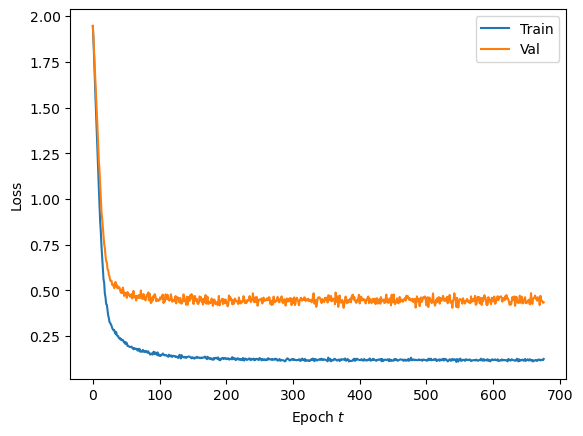

Accuracy of the model: 85.65%


GCN(
  (activation): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (gcn_0): ChainableGCNConv(2879, 64)
      (activation_0): ReLU()
      (dropout_0): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (gcn_1): ChainableGCNConv(64, 7)
    )
  )
)

In [3]:
import torch

train_statistics = experiment_train.run(
    data_dir='./data',
    dataset=DATASET,
    model_params=dict(
        label=MODEL_LABEL,
        model=MODEL_NAME,
        do_cache_adj_prep=True,
        n_filters=64,
        dropout=DROPOUT_VICTIM,
        svd_params=None,
        jaccard_params=None,
        gdc_params={"alpha": 0.15, "k": 64},
    ),
    train_params=dict(
        lr=LR_VICTIM,
        weight_decay=WEIGHT_DECAY_VICTIM,
        patience=PATIENCE_VICTIM,
        max_epochs=MAX_EPOCHS_VICTIM,
    ),
    binary_attr=False,
    make_undirected=True,
    seed=SEED,
    artifact_dir='cache',
    model_storage_type='demo_custom_split',
    ppr_cache_params=dict(),
    device="cpu",
    data_device="cpu",
    display_steps=100,
    debug_level="info",
    custom_split_ratios=(TRAIN_RATIO, VAL_RATIO, TEST_RATIO),
)

# plot train and val loss curves
fig, ax = plt.subplots()

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.plot(train_statistics['trace_train'], color=color, label='Train')

color = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
ax.plot(train_statistics['trace_val'], color=color, label='Val')
ax.legend()
plt.show()

clean_acc = train_statistics["accuracy"]
print(f'Accuracy of the model: {100*clean_acc:.2f}%')

model = train_statistics["model"]
graph = train_statistics["graph"]
idx_train = train_statistics["idx_train"]
idx_val = train_statistics["idx_val"]
idx_test = train_statistics["idx_test"]
model.eval()

In [4]:
import torch

attr_matrix, adj_matrix, labels_raw = graph[:3]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Display ────────────────────────────────────────────────────────────────
n_nodes = adj_matrix.sizes()[0]
n_edges_directed = adj_matrix.nnz()
n_undirected = n_edges_directed // 2

print(f"nodes={n_nodes}")
print(f"Directed edges: {n_edges_directed}")
print(f"Undirected edges: {n_undirected}")
print(f"features={attr_matrix.shape}")
print(f"classes={len(torch.unique(labels_raw))}")

# ── Convert adjacency SparseTensor -> edge_index / edge_weight ─────────────
row, col, value = adj_matrix.coo()

edge_index = torch.stack([row, col], dim=0).long().to(device)

if value is None:
    edge_weight = torch.ones(edge_index.size(1), dtype=torch.float32, device=device)
else:
    edge_weight = value.float().to(device)

# ── Convert features / labels ──────────────────────────────────────────────
attr = attr_matrix.float().to(device)
labels = labels_raw.long().to(device)

# ── Safety checks ──────────────────────────────────────────────────────────
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)
print("max node id in edge_index:", int(edge_index.max()))
print("n_nodes:", n_nodes)

assert int(edge_index.max()) < n_nodes
assert attr.shape[0] == n_nodes
assert labels.shape[0] == n_nodes
'''
train_idx_np, val_idx_np, test_idx_np = train_val_test_split(
    graph.labels,
    train_size=0.05,
    val_size=0.05,
    test_size=0.9,
    mode="stratified",
    seed=SEED,
)

train_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)
val_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)
test_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'''

nodes=2810
Directed edges: 15962
Undirected edges: 7981
features=torch.Size([2810, 2879])
classes=7
edge_index shape: torch.Size([2, 15962])
edge_weight shape: torch.Size([15962])
max node id in edge_index: 2809
n_nodes: 2810


'\ntrain_idx_np, val_idx_np, test_idx_np = train_val_test_split(\n    graph.labels,\n    train_size=0.05,\n    val_size=0.05,\n    test_size=0.9,\n    mode="stratified",\n    seed=SEED,\n)\n\ntrain_idx = torch.as_tensor(train_idx_np, dtype=torch.long, device=device)\nval_idx = torch.as_tensor(val_idx_np, dtype=torch.long, device=device)\ntest_idx = torch.as_tensor(test_idx_np, dtype=torch.long, device=device)'

In [5]:
from helpers.selector_pipeline_helpers import EndpointPRBCDV4Scorer, _edge_set
import random

# ── Candidate sampling ──────────────────────────────────────────────────────
budget = max(1, round(PRBCD_BUDGET_FRACTION * n_undirected))

if USE_PRBCD_CANDIDATES:
    # ── Run endpointPRBCD/V4-style scorer ───────────────────────────────────
    scorer = EndpointPRBCDV4Scorer(
        n=n_nodes,
        edge_index=edge_index,
        edge_weight=edge_weight,
        attr=attr,
        labels=labels,
        attacked_model=model,
        idx_attack=idx_test,
        test_idx=idx_val,
        device=device,
        block_size=PRBCD_SEARCH_SPACE,
        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,

        n_subsets=N_SUBSETS,
        subset_fraction=SUBSET_FRACTION,
        balance_ratio=BALANCE_RATIO,
        store_candidates=True,
    )

    candidates = scorer.mine_prbcd_endpoint_candidates(
        n_perturbations=budget,
        tag="endpointPRBCD",
        rng_seed=SEED,
        n_candidates=PRBCD_SEARCH_SPACE,
        prbcd_epochs=PRBCD_EPOCHS,
        n_prbcd_runs=N_PRBCD_RUNS,
        n_epochs_resampling=PRBCD_N_EPOCHS_RESAMPLING,
    )

else:
    # same candidate count as PRBCD budget over all runs:
    # num_edges * budget_fraction * n_prbcd_runs
    n_random_candidates = max(
        1,
        round(n_undirected * PRBCD_BUDGET_FRACTION * N_PRBCD_RUNS)
    )

    rng = random.Random(SEED)
    candidates_set = set()

    while len(candidates_set) < n_random_candidates:
        u = rng.randrange(n_nodes)
        v = rng.randrange(n_nodes)

        if u == v:
            continue

        candidates_set.add((min(u, v), max(u, v)))

    candidates = list(candidates_set)

# ── Inspect mined / sampled candidates ──────────────────────────────────────
print(f"Candidates: {len(candidates)}")

orig_edges = _edge_set(edge_index)
n_cands    = len(candidates)
n_removals = sum(1 for e in candidates if e in orig_edges)
n_adds     = n_cands - n_removals

print(f"Candidates: {n_cands}  ({n_adds} additions, {n_removals} removals)")
print(f"Original edges: {orig_edges}")

Candidates: 11972
Candidates: 11972  (11956 additions, 16 removals)
Original edges: {(1042, 2704), (1560, 2401), (1656, 2109), (2736, 2741), (571, 2301), (924, 1436), (1106, 1184), (460, 2470), (191, 1787), (1693, 1883), (514, 2706), (2016, 2802), (2773, 2781), (1159, 1195), (2437, 2795), (797, 2240), (1406, 2055), (1072, 2704), (1101, 1190), (1309, 2122), (142, 1787), (264, 464), (1103, 1236), (1308, 1668), (714, 1195), (1115, 2293), (573, 1973), (1404, 2130), (1412, 1991), (1977, 2702), (1532, 1534), (611, 2615), (2015, 2176), (1454, 1614), (1863, 2802), (505, 913), (726, 1555), (731, 2653), (231, 529), (64, 123), (34, 1678), (2116, 2349), (2677, 2682), (510, 1378), (97, 1468), (959, 975), (236, 351), (1368, 1668), (2739, 2742), (984, 1971), (285, 1933), (1189, 2605), (1127, 1727), (270, 349), (498, 1933), (102, 1933), (1893, 1903), (189, 2346), (1195, 2275), (11, 1293), (1592, 1682), (45, 123), (31, 188), (1390, 2487), (719, 2282), (818, 1507), (2248, 2252), (529, 1404), (590, 596),

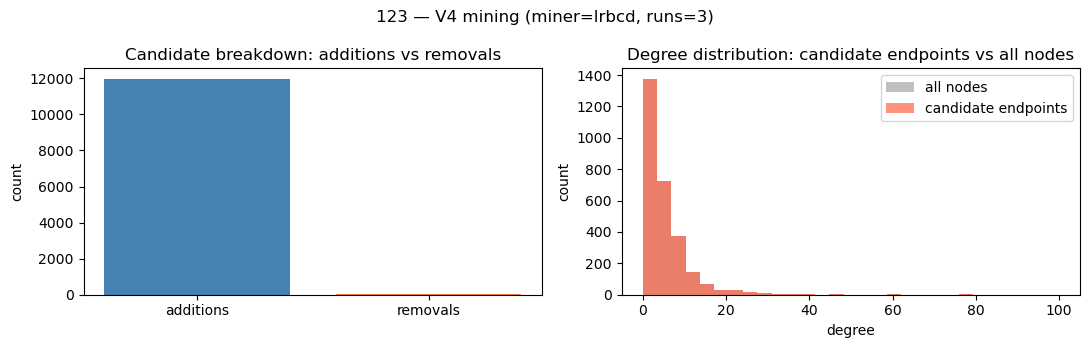

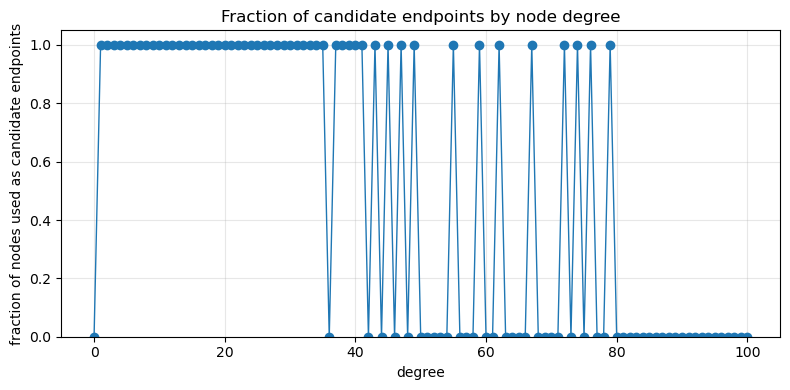

In [6]:
degrees    = np.bincount(edge_index[0].cpu().numpy(), minlength=n_nodes)
cand_nodes = set(u for u, v in candidates) | set(v for u, v in candidates)
cand_degs  = degrees[list(cand_nodes)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['additions', 'removals'], [n_adds, n_removals], color=['steelblue', 'coral'])
axes[0].set_title('Candidate breakdown: additions vs removals')
axes[0].set_ylabel('count')

bins = np.linspace(0, min(degrees.max(), 100), 30)
axes[1].hist(degrees,     bins=bins, alpha=0.5, label='all nodes',          color='grey')
axes[1].hist(cand_degs,   bins=bins, alpha=0.7, label='candidate endpoints', color='tomato')
axes[1].set_title('Degree distribution: candidate endpoints vs all nodes')
axes[1].set_xlabel('degree'); axes[1].set_ylabel('count'); axes[1].legend()

plt.suptitle(f'{123} — V4 mining (miner={MINER}, runs={N_PRBCD_RUNS})', fontsize=12)
plt.tight_layout()
plt.show()

# Fraction of nodes per degree that appear as candidate endpoints
all_degree_counts = np.bincount(degrees)

candidate_endpoint_mask = np.zeros(n_nodes, dtype=bool)
candidate_endpoint_mask[list(cand_nodes)] = True

candidate_degree_counts = np.bincount(
    degrees[candidate_endpoint_mask],
    minlength=len(all_degree_counts)
)

candidate_fraction_by_degree = np.divide(
    candidate_degree_counts,
    all_degree_counts,
    out=np.zeros_like(candidate_degree_counts, dtype=float),
    where=all_degree_counts > 0
)

# Optional: restrict to visible degree range
max_degree_plot = min(degrees.max(), 100)
degree_values = np.arange(max_degree_plot + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    degree_values,
    candidate_fraction_by_degree[:max_degree_plot + 1],
    marker="o",
    linewidth=1,
)

plt.title("Fraction of candidate endpoints by node degree")
plt.xlabel("degree")
plt.ylabel("fraction of nodes used as candidate endpoints")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print("vor breakpoint")
print("nach breakpoint")

import sys
print(sys.executable)
print(sys.version)

vor breakpoint
nach breakpoint
E:\Anaconda\envs\Masterarbeit\python.exe
3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]


---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool, apply each subset jointly, and measure test-accuracy drop.  Each edge accumulates the drops of every subset it was in; the raw scores are normalised globally to [0, 1].

**Key diagnostics:**
- Accuracy drop per subset — are subsets actually harming the model?
- Distribution of raw accumulated scores — how skewed is it?
- Fraction of candidates with score > 0 — coverage.

In [8]:
from pathlib import Path

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores,
    save_mining_output,
    load_mining_output,
    _dense_adj,
)

adj_orig    = _dense_adj(edge_index, n_nodes, device=device)
cand_src    = [u for u, v in candidates]
cand_dst    = [v for u, v in candidates]
exists_list = [float(adj_orig[u, v].item()) for u, v in candidates]

MINING_MODE = "endpoint"

CACHE_PATH = Path(
    "cache"
) / (
    f"candidate_mining_"
    f"mode-{MINING_MODE}_"
    f"seed-{SEED}_"
    f"candidates-{len(candidates)}.pt"
)

cache_metadata = {
    "mode": MINING_MODE,
    "seed": int(SEED),
    "n_nodes": int(n_nodes),
    "n_candidates": int(len(candidates)),
    "subset_fraction": float(SUBSET_FRACTION),
    "n_subsets": int(N_SUBSETS),
    "endpoint_require_correct_to_incorrect": True,
}


if CACHE_PATH.exists():
    mining_result, cached_candidates, stored_metadata = (
        load_mining_output(
            CACHE_PATH,
            device=device,
            expected_metadata=cache_metadata,
        )
    )

    # Optional additional safety check.
    if cached_candidates != candidates:
        raise ValueError(
            "The candidates in the cache differ from the "
            "current candidates."
        )

else:
    mining_result = mine_candidate_edge_scores(
        model=model,
        attr=attr,
        edge_index=edge_index,
        labels=labels,
        eval_idx=idx_test,
        candidates=candidates,
        n_nodes=n_nodes,
        mode=MINING_MODE,

        subset_fraction=SUBSET_FRACTION,
        n_subsets=N_SUBSETS,

        endpoint_k_samples=None,
        endpoint_require_correct_to_incorrect=True,

        two_hop_k_samples=None,

        seed=SEED,
        device=device,
        verbose=True,
    )

    save_mining_output(
        CACHE_PATH,
        mining_result,
        candidates=candidates,
        metadata=cache_metadata,
    )

labels_raw = mining_result["labels_raw"]
labels_norm = mining_result["labels_norm"]
clean_acc_v = mining_result["clean_accuracy"]

print(f"Clean test accuracy: {clean_acc_v:.4f}")


if MINING_MODE == "subset_accuracy_drop":
    drop_per_subset = mining_result["drop_per_subset"]
    subset_size = mining_result["subset_size"]

    max_raw = (
        float(labels_raw.max())
        if len(labels_raw) > 0
        else 0.0
    )

    n_pos = int((labels_norm > 0).sum())

    print(
        f"Subset size: {subset_size} "
        f"({SUBSET_FRACTION:.0%} of "
        f"{len(candidates)} candidates)"
    )

    print(f"\nSubsets run: {N_SUBSETS}")

    print(
        "Accuracy drop per subset: "
        f"mean={drop_per_subset.mean():.4f}  "
        f"max={drop_per_subset.max():.4f}  "
        f"zero_rate={(drop_per_subset == 0).mean():.2%}"
    )

    print(
        f"Edges with score > 0: "
        f"{n_pos}/{len(candidates)} "
        f"({100 * n_pos / len(candidates):.1f}%)"
    )

    print(
        f"Raw score stats: "
        f"max={max_raw:.4f}  "
        f"mean={labels_raw.mean():.4f}"
    )

elif MINING_MODE == "endpoint":
    endpoint_labels = np.asarray(
        mining_result["endpoint_labels"]
    )

    u_hit_labels = np.asarray(
        mining_result["u_hit_labels"]
    )

    v_hit_labels = np.asarray(
        mining_result["v_hit_labels"]
    )

    both_hit_labels = np.asarray(
        mining_result["both_hit_labels"]
    )

    sampled_edge_index = mining_result[
        "sampled_edge_index"
    ]

    n_selected = int(
        mining_result["n_samples"]
    )

    endpoint_hits = int(
        endpoint_labels.sum()
    )

    u_hits = int(
        u_hit_labels.sum()
    )

    v_hits = int(
        v_hit_labels.sum()
    )

    both_hits = int(
        both_hit_labels.sum()
    )

    n_positive = endpoint_hits

    endpoint_hit_rate = (
        endpoint_hits / n_selected
        if n_selected > 0
        else 0.0
    )

    print(
        f"Original candidate pairs evaluated: "
        f"{n_selected}"
    )

    print(
        f"Endpoint hits: "
        f"{endpoint_hits}/{n_selected} "
        f"({endpoint_hit_rate:.2%})"
    )

    print(
        f"u hits={u_hits}  "
        f"v hits={v_hits}  "
        f"both hits={both_hits}"
    )

    print(
        f"Positive endpoint labels: "
        f"{n_positive}/{n_selected}"
    )

    print(
        f"Candidate edge tensor shape: "
        f"{tuple(sampled_edge_index.shape)}"
    )

    assert sampled_edge_index.ndim == 2
    assert sampled_edge_index.shape[0] == 2
    assert sampled_edge_index.shape[1] == n_selected
    assert endpoint_labels.shape[0] == n_selected
    assert u_hit_labels.shape[0] == n_selected
    assert v_hit_labels.shape[0] == n_selected
    assert both_hit_labels.shape[0] == n_selected


elif MINING_MODE == "two_hop_correct_to_incorrect":
    sampled_edge_index = mining_result["sampled_edge_index"]

    n_samples = mining_result["n_samples"]
    n_unique_candidates = mining_result[
        "n_unique_candidates"
    ]

    positive_flips = mining_result["positive_flips"]

    total_correct_to_incorrect = mining_result[
        "total_correct_to_incorrect"
    ]

    mean_raw_score = mining_result["mean_raw_score"]
    raw_score_min = mining_result["raw_score_min"]
    raw_score_max = mining_result["raw_score_max"]

    mean_neighborhood_size = mining_result[
        "mean_neighborhood_size"
    ]

    neighborhood_sizes = mining_result[
        "neighborhood_sizes"
    ]

    print(
        f"Two-hop candidate edges evaluated: "
        f"{n_samples}/{n_unique_candidates}"
    )

    print(
        f"Flips causing at least one "
        f"correct-to-incorrect transition: "
        f"{positive_flips}/{n_samples} "
        f"({positive_flips / n_samples:.2%})"
    )

    print(
        f"Total correct-to-incorrect transitions: "
        f"{total_correct_to_incorrect}"
    )

    print(
        f"Raw score stats: "
        f"min={raw_score_min:.0f}  "
        f"max={raw_score_max:.0f}  "
        f"mean={mean_raw_score:.4f}"
    )

    print(
        f"Normalized score stats: "
        f"min={labels_norm.min():.4f}  "
        f"max={labels_norm.max():.4f}  "
        f"mean={labels_norm.mean():.4f}"
    )

    print(
        f"Mean two-hop union-neighborhood size: "
        f"{mean_neighborhood_size:.2f}"
    )

    print(
        f"Neighborhood-size range: "
        f"{neighborhood_sizes.min()}–"
        f"{neighborhood_sizes.max()}"
    )

    print(
        f"Sampled edge tensor shape: "
        f"{tuple(sampled_edge_index.shape)}"
    )


else:
    raise ValueError(
        f"Unknown MINING_MODE: {MINING_MODE}"
    )

[MINING CACHE] Loaded mining output from: cache\candidate_mining_mode-endpoint_seed-0_candidates-11972.pt
Clean test accuracy: 0.8565
Original candidate pairs evaluated: 11972
Endpoint hits: 1048/11972 (8.75%)
u hits=539  v hits=512  both hits=3
Positive endpoint labels: 1048/11972
Candidate edge tensor shape: (2, 11972)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Drop per subset over time
axes[0].plot(np.arange(1, N_SUBSETS + 1), drop_per_subset,
             marker='o', markersize=3, linewidth=1, color='steelblue')
axes[0].axhline(drop_per_subset.mean(), color='tomato', linestyle='--', linewidth=1.2,
                label=f'mean = {drop_per_subset.mean():.4f}')
axes[0].set_xlabel('subset index'); axes[0].set_ylabel('accuracy drop')
axes[0].set_title('Accuracy drop per sampled subset')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Distribution of accuracy drops
axes[1].hist(drop_per_subset, bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel('accuracy drop'); axes[1].set_ylabel('count')
axes[1].set_title('Distribution of per-subset accuracy drops')
axes[1].grid(True, alpha=0.3)

# Distribution of raw edge scores
axes[2].hist(labels_raw[labels_raw > 0], bins=30, color='tomato',
             edgecolor='white', label=f'scored ({n_pos})')
axes[2].set_xlabel('raw accumulated drop sum'); axes[2].set_ylabel('count')
axes[2].set_title(f'Per-edge raw score distribution  ({n_cands - n_pos} edges at 0 not shown)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{234} — V4 subset scoring  (n_subsets={N_SUBSETS}, subset_size={subset_size})', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'drop_per_subset' is not defined

---
## §3  Label Distribution

After global normalisation the labels are continuous in [0, 1].  Unlike V1–V3 (binary 0/1), V4 labels represent a **relative harmfulness score** — the edge with the highest total accumulated accuracy drop receives 1.0.

In [10]:
n_pos = int((labels_norm > 0).sum())

Label stats:
  min=0.0000  mean=0.0875  max=1.0000  std=0.2826
  Fraction with label > 0: 0.088
  Fraction with label > 0.5: 0.088


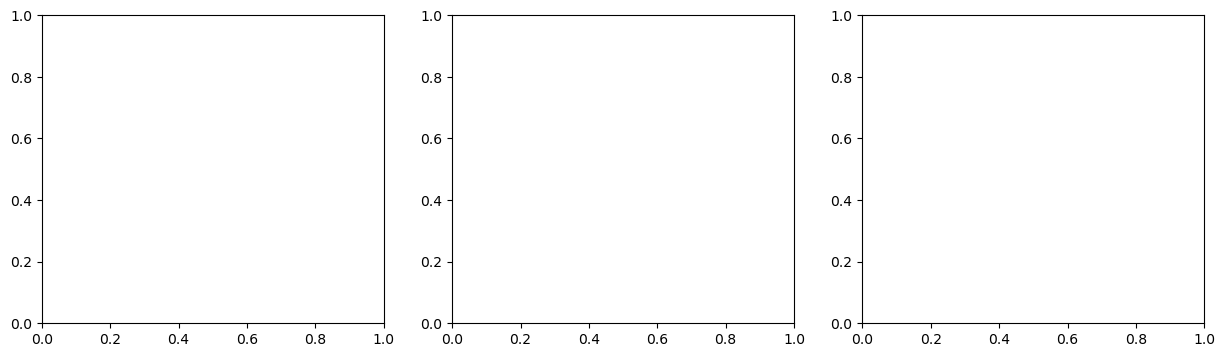

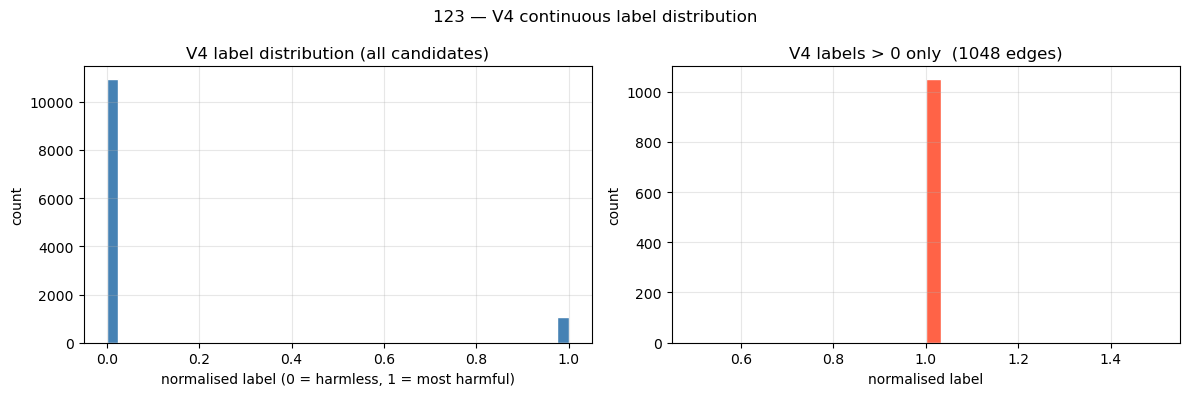

In [11]:
''# Convert to tensors for scorer use
src    = torch.tensor(cand_src,    dtype=torch.long,    device=device)
dst    = torch.tensor(cand_dst,    dtype=torch.long,    device=device)
labels_changed = torch.tensor(labels_norm, dtype=torch.float32, device=device)
exists = torch.tensor(exists_list, dtype=torch.float32, device=device)

print('Label stats:')
print(f'  min={float(labels_changed.min()):.4f}  mean={float(labels_changed.mean()):.4f}  '
      f'max={float(labels_changed.max()):.4f}  std={float(labels_changed.std()):.4f}')
print(f'  Fraction with label > 0: {(labels_changed > 0).float().mean():.3f}')
print(f'  Fraction with label > 0.5: {(labels_changed > 0.5).float().mean():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lbl_np = labels_changed.cpu().numpy()
axes[0].hist(lbl_np, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('normalised label (0 = harmless, 1 = most harmful)')
axes[0].set_ylabel('count')
axes[0].set_title('V4 label distribution (all candidates)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(lbl_np[lbl_np > 0], bins=30, color='tomato', edgecolor='white')
axes[1].set_xlabel('normalised label')
axes[1].set_ylabel('count')
axes[1].set_title(f'V4 labels > 0 only  ({n_pos} edges)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 continuous label distribution', fontsize=12)
plt.tight_layout()
plt.show()

---
## §4  Oracle Check — Top-Scored vs Random Subsets

Apply the top-k edges by V4 label jointly and compare accuracy with applying k random candidate edges.  If the labels are informative, the top-scored selection should consistently produce larger accuracy drops.

In [12]:
from helpers.selector_pipeline_helpers import accuracy
import pandas as pd

BLOCK_STEP_ORACLE = 10

sort_order = labels_changed.cpu().argsort(descending=True)
print(labels_changed[1])
print(labels_changed[2993])
print(labels_changed[3221])
all_idx = np.arange(n_cands)
block_sizes = list(range(0, n_cands, BLOCK_STEP_ORACLE))
if not block_sizes or block_sizes[-1] != n_cands:
    block_sizes.append(n_cands)

rng_o = np.random.default_rng(42)
rows_o = []

for k in block_sizes:
    # Top-k by V4 label
    adj_top = adj_orig.clone()
    if k > 0:
        for i in sort_order[:k].tolist():
            u, v = cand_src[i], cand_dst[i]
            adj_top[u, v] = 1.0 - exists_list[i]
            adj_top[v, u] = 1.0 - exists_list[i]

    test_acc = accuracy(model, attr, labels, idx_test, edge_index=adj_top)

    rows_o.append({
        'k': k,
        'attack': 'top-k by V4 label',
        'test_accuracy': test_acc
    })

    # Random k from all candidates
    adj_rnd = adj_orig.clone()
    if k > 0:
        for i in rng_o.choice(all_idx, size=min(k, n_cands), replace=False).tolist():
            u, v = cand_src[i], cand_dst[i]
            adj_rnd[u, v] = 1.0 - exists_list[i]
            adj_rnd[v, u] = 1.0 - exists_list[i]

    rows_o.append({
        'k': k,
        'attack': 'random candidates',
        'test_accuracy': accuracy(model, attr, labels, idx_test, edge_index=adj_rnd)
    })

oracle_df = pd.DataFrame(rows_o)
display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').tail(20))

tensor(0.)
tensor(0.)
tensor(0.)


attack,random candidates,top-k by V4 label
k,,
11790,0.784104,0.785291
11800,0.787663,0.785291
11810,0.787663,0.785291
11820,0.787663,0.785291
11830,0.787663,0.782918
11840,0.785291,0.782918
11850,0.788849,0.784104
11860,0.786477,0.784104
11870,0.786477,0.784104


In [13]:
display(oracle_df.pivot_table(index='k', columns='attack', values='test_accuracy').head(20))

attack,random candidates,top-k by V4 label
k,,
0,0.856465,0.856465
10,0.854093,0.854093
20,0.857651,0.852906
30,0.857651,0.848161
40,0.857651,0.845789
50,0.857651,0.841044
60,0.855279,0.841044
70,0.852906,0.838671
80,0.856465,0.833926


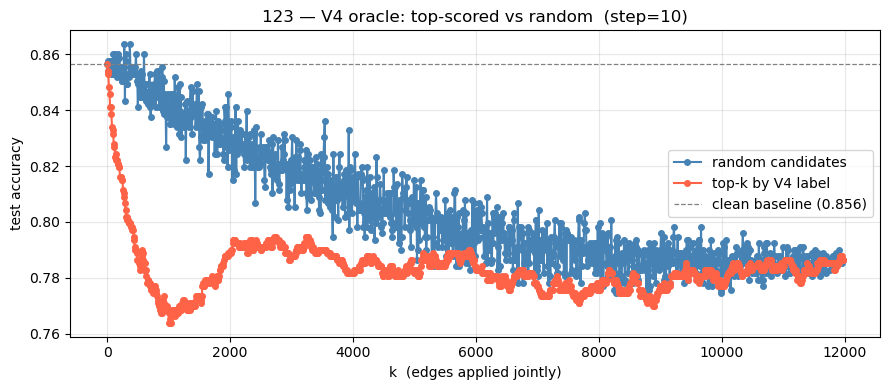

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
for attack, grp in oracle_df.groupby('attack'):
    color = 'tomato' if 'V4' in attack else 'steelblue'
    ax.plot(grp['k'], grp['test_accuracy'], marker='o', markersize=4,
            label=attack, color=color)
ax.axhline(clean_acc, color='grey', linestyle='--', linewidth=0.9,
           label=f'clean baseline ({clean_acc:.3f})')
ax.set_xlabel('k  (edges applied jointly)'); ax.set_ylabel('test accuracy')
ax.set_title(f'{123} — V4 oracle: top-scored vs random  (step={BLOCK_STEP_ORACLE})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
from helpers.selector_pipeline_helpers import train_link_prediction_gnn

LABEL_MODE = "continuous"  # "projected" or "continuous"
EXTREME_FRACTION = 0.1

attacker_x = attr
edge_index_struct = edge_index

scores = labels_changed.float().flatten()

valid_mask = torch.isfinite(scores)

src_valid = src[valid_mask]
dst_valid = dst[valid_mask]
scores_valid = scores[valid_mask]
exists_valid = exists[valid_mask]

if LABEL_MODE == "continuous":
    # Use the continuous values directly.
    src_bal = src_valid
    dst_bal = dst_valid
    lbl_bal = scores_valid
    ex_bal = exists_valid

elif LABEL_MODE == "projected":
    if not 0.0 < EXTREME_FRACTION <= 0.5:
        raise ValueError(
            "EXTREME_FRACTION must be between 0 and 0.5."
        )

    n_valid = scores_valid.numel()
    n_per_class = max(
        1,
        min(
            int(n_valid * EXTREME_FRACTION),
            n_valid // 2,
        ),
    )

    # Sort from lowest to highest score.
    order = torch.argsort(scores_valid)

    low_idx = order[:n_per_class]
    high_idx = order[-n_per_class:]

    # Lowest scores -> 0
    # Highest scores -> 1
    selected_idx = torch.cat([low_idx, high_idx])

    src_bal = src_valid[selected_idx]
    dst_bal = dst_valid[selected_idx]
    ex_bal = exists_valid[selected_idx]

    lbl_bal = torch.cat([
        torch.zeros(
            n_per_class,
            device=scores_valid.device,
            dtype=torch.float32,
        ),
        torch.ones(
            n_per_class,
            device=scores_valid.device,
            dtype=torch.float32,
        ),
    ])

else:
    raise ValueError(
        "LABEL_MODE must be 'continuous' or 'projected'."
    )

edge_index_bal = torch.stack(
    [src_bal.long(), dst_bal.long()],
    dim=0,
)

lbl_bal = lbl_bal.float()

lp_model = train_link_prediction_gnn(
    x=attacker_x,
    edge_index_struct=edge_index_struct,
    edge_index_lab=edge_index_bal,
    y_label=lbl_bal,
    device=device,
    num_epochs=200,
    hidden_dim=64,
    out_dim=64,
    lr=5e-4,
    weight_decay=5e-4,
    use_tqdm=True,
    verbose=True,

    early_stop=True,
    early_stop_metric="val_loss",
    min_epochs_before_early_stop=100,
    early_stop_patience=15,
    early_stop_min_delta=1e-4,
    restore_best=True,

    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    threshold=0.5,
)

[LP-GNN] Training:   1%|          | 2/200 [00:00<00:15, 12.81it/s, tr_bce=1.2672, tr_obj=1.5156, va_loss=1.2671, va_mae=0.520, va_rmse=0.520, va_ap=0.084, va_auc=0.489, va_f1=0.161, pat=15]

[LP-GNN] Labeled pairs: M=11972 | mode=hard_binary | pos=1048 | neg=10924
[LP-GNN] Split strategy=threshold_stratified | train=8379 | val=1795 | test=1798
[LP-GNN] Epoch 001/200 | train_bce=1.2669 | train_objective=1.5167 | val_loss=1.2668 | test_loss=1.2693 | val_mae=0.5187 | val_rmse=0.5188 | train_acc=0.0875 | val_acc=0.0875 | test_acc=0.0879 | val_precision=0.0875 | val_recall=1.0000 | val_f1=0.1609 | val_TP/FP/TN/FN=157/1638/0/0 | val_R2=-2.3727 | val_Pearson=-0.0085 | val_AUC=0.5081 | val_AP=0.0879 | best_val_loss=1.2668 (epoch 1) | patience_left=15 | new_best


[LP-GNN] Training:  11%|█         | 22/200 [00:01<00:13, 13.29it/s, tr_bce=1.2934, tr_obj=1.4893, va_loss=1.2954, va_mae=0.570, va_rmse=0.572, va_ap=0.073, va_auc=0.434, va_f1=0.161, pat=15]

[LP-GNN] Epoch 020/200 | train_bce=1.2877 | train_objective=1.4917 | val_loss=1.2891 | test_loss=1.2909 | val_mae=0.5621 | val_rmse=0.5637 | train_acc=0.0875 | val_acc=0.0875 | test_acc=0.0879 | val_precision=0.0875 | val_recall=1.0000 | val_f1=0.1609 | val_TP/FP/TN/FN=157/1638/0/0 | val_R2=-2.9815 | val_Pearson=-0.0701 | val_AUC=0.4303 | val_AP=0.0721 | best_val_loss=1.2668 (epoch 1) | patience_left=15


[LP-GNN] Training:  21%|██        | 42/200 [00:03<00:11, 13.57it/s, tr_bce=1.2843, tr_obj=1.4711, va_loss=1.2969, va_mae=0.581, va_rmse=0.584, va_ap=0.119, va_auc=0.544, va_f1=0.161, pat=15]

...

[LP-GNN] Epoch 120/200 | train_bce=0.7138 | train_objective=1.1092 | val_loss=0.9598 | test_loss=0.9976 | val_mae=0.4320 | val_rmse=0.4642 | train_acc=0.7877 | val_acc=0.7565 | test_acc=0.7353 | val_precision=0.2398 | val_recall=0.8217 | val_f1=0.3712 | val_TP/FP/TN/FN=129/409/1229/28 | val_R2=-1.6992 | val_Pearson=0.4172 | val_AUC=0.8451 | val_AP=0.3977 | best_val_loss=0.9598 (epoch 120) | patience_left=15 | new_best


[LP-GNN] Training:  71%|███████   | 142/200 [00:10<00:04, 12.62it/s, tr_bce=0.6419, tr_obj=1.0540, va_loss=0.9532, va_mae=0.423, va_rmse=0.456, va_ap=0.408, va_auc=0.846, va_f1=0.394, pat=11]

[LP-GNN] Epoch 140/200 | train_bce=0.6416 | train_objective=1.0583 | val_loss=0.9514 | test_loss=0.9936 | val_mae=0.4190 | val_rmse=0.4513 | train_acc=0.8484 | val_acc=0.8028 | test_acc=0.7775 | val_precision=0.2715 | val_recall=0.7452 | val_f1=0.3980 | val_TP/FP/TN/FN=117/314/1324/40 | val_R2=-1.5523 | val_Pearson=0.4337 | val_AUC=0.8463 | val_AP=0.4082 | best_val_loss=0.9508 (epoch 138) | patience_left=13


[LP-GNN] Training:  76%|███████▌  | 152/200 [00:11<00:03, 12.94it/s, tr_bce=0.6104, tr_obj=1.0344, va_loss=0.9521, va_mae=0.416, va_rmse=0.450, va_ap=0.411, va_auc=0.843, va_f1=0.401, pat=0] 

[LP-GNN] Early stopping at epoch 153. Best val_loss=0.9508 at epoch 138.
[LP-GNN] Restored best model from epoch 138 (val_loss=0.9508).
[LP-GNN] Training complete after 153 epoch(s). stop_reason=early_stopping | label_mode=hard_binary | best_epoch=138 | best_val_loss=0.9507972598075867.


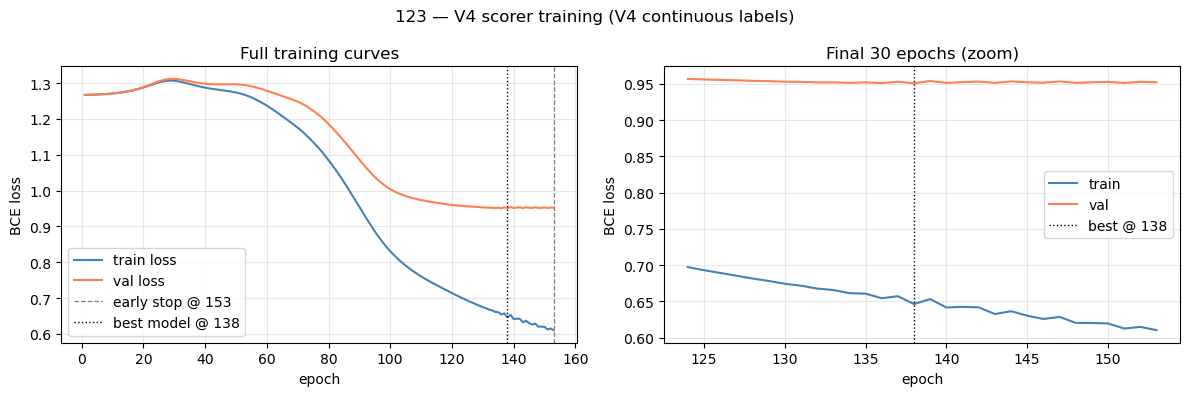

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Use `self.lp_model` inside the PRBCD class/notebook context.
# Replace with `model` when the returned model is stored under another name.
history = lp_model.training_history

train_losses = np.asarray(
    history["train_losses"],
    dtype=float,
)
val_losses = np.asarray(
    history["val_losses"],
    dtype=float,
)

stopped_at = int(history["stopped_at"])
best_epoch = history.get("best_epoch")
early_stopped = bool(history.get("early_stopped", False))

epochs_run = len(train_losses)

if epochs_run == 0:
    raise RuntimeError(
        "No completed training epochs are available for plotting."
    )

if len(val_losses) != epochs_run:
    raise RuntimeError(
        "train_losses and val_losses have different lengths: "
        f"{epochs_run} and {len(val_losses)}."
    )

ep_axis = np.arange(1, epochs_run + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

# ==========================================================
# Full training curves
# ==========================================================

axes[0].plot(
    ep_axis,
    train_losses,
    label="train loss",
    color="steelblue",
)

axes[0].plot(
    ep_axis,
    val_losses,
    label="val loss",
    color="coral",
)

stop_label = (
    f"early stop @ {stopped_at}"
    if early_stopped
    else f"training ended @ {stopped_at}"
)

axes[0].axvline(
    stopped_at,
    color="grey",
    linestyle="--",
    linewidth=0.9,
    label=stop_label,
)

if best_epoch is not None:
    axes[0].axvline(
        best_epoch,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=f"best model @ {best_epoch}",
    )

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Full training curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==========================================================
# Final epochs
# ==========================================================

z = min(30, epochs_run)

axes[1].plot(
    ep_axis[-z:],
    train_losses[-z:],
    label="train",
    color="steelblue",
)

axes[1].plot(
    ep_axis[-z:],
    val_losses[-z:],
    label="val",
    color="coral",
)

if best_epoch is not None and best_epoch >= ep_axis[-z]:
    axes[1].axvline(
        best_epoch,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=f"best @ {best_epoch}",
    )

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("BCE loss")
axes[1].set_title(f"Final {z} epochs (zoom)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "123 — V4 scorer training (V4 continuous labels)",
    fontsize=12,
)

plt.tight_layout()
plt.show()

Random candidate pool:
  nodes:                    2,810
  all possible pairs:       3,946,645
  sampled candidates:       11,972
  edge-addition candidates: 11,949
  edge-deletion candidates: 23

Selector score statistics:
  min:    0.080922
  mean:   0.458201
  median: 0.387727
  max:    0.996487

Top 10 candidates predicted by the LP-GNN:


,rank,candidate_idx,src,dst,exists,action,selector_score
0,1,6208,877,2035,0,add,0.996487
1,2,2558,903,2684,0,add,0.996390
2,3,957,1429,2096,0,add,0.994100
3,4,2980,992,2310,0,add,0.993554
4,5,8366,1582,2002,0,add,0.993387
5,6,8826,1314,1870,0,add,0.993304
6,7,2310,725,2096,0,add,0.993139
7,8,489,259,2094,0,add,0.992105
8,9,2718,1356,2074,0,add,0.991958
9,10,4681,811,2096,0,add,0.991390


[LP-GNN] Training:  76%|███████▌  | 152/200 [00:30<00:03, 12.94it/s, tr_bce=0.6104, tr_obj=1.0344, va_loss=0.9521, va_mae=0.416, va_rmse=0.450, va_ap=0.411, va_auc=0.843, va_f1=0.401, pat=0]

,k,lp_gnn_accuracy,random_mean,random_std,random_min,random_max,lp_gnn_advantage
0,0,0.856465,0.856465,0.000000,0.856465,0.856465,0.000000
1,10,0.855279,0.856228,0.001225,0.854093,0.857651,0.000949
2,20,0.855279,0.857058,0.001876,0.852906,0.858837,0.001779
3,30,0.855279,0.857177,0.002575,0.851720,0.861210,0.001898
4,40,0.851720,0.857414,0.003001,0.851720,0.862396,0.005694
5,50,0.849348,0.857533,0.003035,0.852906,0.862396,0.008185
6,60,0.849348,0.857414,0.002948,0.852906,0.862396,0.008066
7,70,0.849348,0.857533,0.002590,0.854093,0.861210,0.008185
8,80,0.848161,0.857414,0.003001,0.852906,0.862396,0.009253
9,90,0.846975,0.856465,0.003355,0.851720,0.861210,0.009490


,k,lp_gnn_accuracy,random_mean,random_std,random_min,random_max,lp_gnn_advantage
1179,11790,0.768683,0.764887,0.003615,0.759193,0.769870,-3.795946e-03
1180,11800,0.768683,0.765362,0.003483,0.760380,0.768683,-3.321457e-03
1181,11810,0.768683,0.765836,0.003318,0.760380,0.769870,-2.846956e-03
1182,11820,0.766311,0.765599,0.003124,0.759193,0.769870,-7.117510e-04
1183,11830,0.766311,0.765599,0.003318,0.759193,0.768683,-7.117510e-04
1184,11840,0.766311,0.765718,0.003320,0.759193,0.769870,-5.931258e-04
1185,11850,0.766311,0.765480,0.002908,0.760380,0.769870,-8.303702e-04
1186,11860,0.767497,0.766429,0.002708,0.761566,0.769870,-1.067632e-03
1187,11870,0.767497,0.766429,0.003770,0.760380,0.772242,-1.067626e-03
1188,11880,0.768683,0.765955,0.003065,0.761566,0.769870,-2.728325e-03


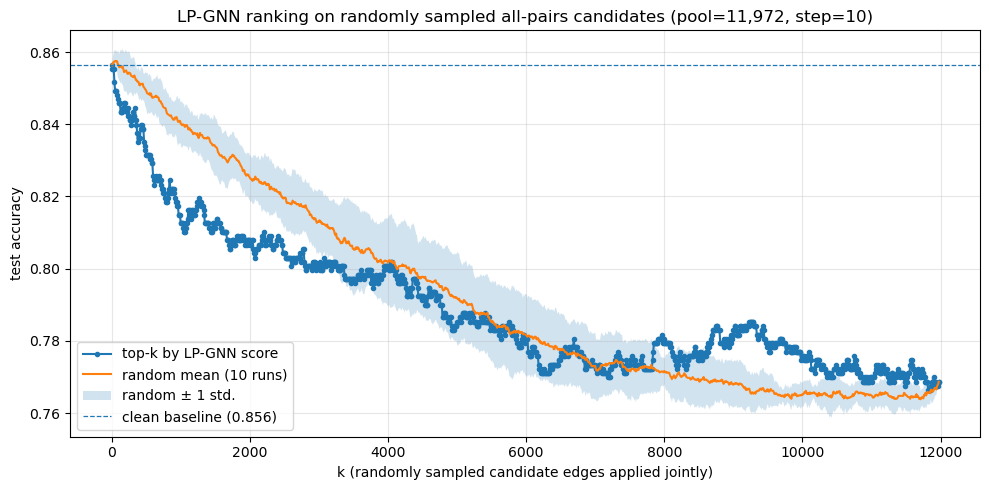

In [18]:
from helpers.selector_pipeline_helpers import accuracy

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ============================================================
# Configuration
# ============================================================

# Number of randomly sampled candidate edges.
N_RANDOM_CANDIDATES = n_cands

# Evaluate the cumulative attack every this many candidates.
BLOCK_STEP_SELECTOR = 10

# Batch size when scoring candidates with the LP-GNN.
SCORE_BATCH_SIZE = 100_000

# Several random orderings produce a more reliable baseline.
N_RANDOM_RUNS = 10

# Reproducibility.
RANDOM_SEED = 42
CANDIDATE_RANDOM_SEED = 123


# ============================================================
# Models
# ============================================================

# LP-GNN trained to prioritize harmful candidate edge flips.
selector_model = lp_model

# Original node-classification model whose accuracy is attacked.
victim_model = model

selector_device = next(
    selector_model.parameters()
).device


# ============================================================
# Random candidate sampling
# ============================================================

def sample_random_undirected_pairs(
    num_nodes: int,
    num_candidates: int,
    seed: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Uniformly sample unique undirected node pairs (u, v), where u < v.

    The complete set of N(N-1)/2 node pairs is never explicitly
    constructed.

    Returns
    -------
    cand_src:
        Source nodes of shape (num_candidates,).

    cand_dst:
        Destination nodes of shape (num_candidates,).
    """

    if num_nodes < 2:
        raise ValueError(
            "The graph must contain at least two nodes."
        )

    total_possible_edges = (
        num_nodes * (num_nodes - 1) // 2
    )

    num_candidates = min(
        int(num_candidates),
        total_possible_edges,
    )

    if num_candidates <= 0:
        raise ValueError(
            "num_candidates must be greater than zero."
        )

    rng = random.Random(seed)

    # Sample unique positions from the flattened upper triangle.
    # range(...) does not construct a Python list containing all
    # possible edge indices.
    sampled_linear_indices = torch.tensor(
        rng.sample(
            range(total_possible_edges),
            num_candidates,
        ),
        dtype=torch.long,
    )

    # Upper-triangle row lengths:
    #
    # row 0 contains N-1 pairs
    # row 1 contains N-2 pairs
    # ...
    # row N-2 contains 1 pair
    row_lengths = torch.arange(
        num_nodes - 1,
        0,
        -1,
        dtype=torch.long,
    )

    # Starting flattened index of each upper-triangle row.
    #
    # For N=4:
    #
    # row 0: (0,1), (0,2), (0,3), start=0
    # row 1: (1,2), (1,3),        start=3
    # row 2: (2,3),               start=5
    row_starts = torch.zeros(
        num_nodes,
        dtype=torch.long,
    )

    row_starts[1:] = torch.cumsum(
        row_lengths,
        dim=0,
    )

    # Find the upper-triangle row belonging to every sampled
    # flattened index.
    cand_src = (
        torch.searchsorted(
            row_starts,
            sampled_linear_indices,
            right=True,
        )
        - 1
    )

    offset_within_row = (
        sampled_linear_indices
        - row_starts[cand_src]
    )

    cand_dst = (
        cand_src
        + 1
        + offset_within_row
    )

    assert torch.all(cand_src < cand_dst)
    assert cand_src.numel() == num_candidates
    assert cand_dst.numel() == num_candidates

    return cand_src, cand_dst


if adj_orig.ndim != 2:
    raise ValueError(
        "adj_orig must be a two-dimensional adjacency matrix."
    )

if adj_orig.size(0) != adj_orig.size(1):
    raise ValueError(
        "adj_orig must be square."
    )

num_nodes = int(adj_orig.size(0))

cand_src_t, cand_dst_t = sample_random_undirected_pairs(
    num_nodes=num_nodes,
    num_candidates=N_RANDOM_CANDIDATES,
    seed=CANDIDATE_RANDOM_SEED,
)

n_cands = cand_src_t.numel()

total_possible_edges = (
    num_nodes * (num_nodes - 1) // 2
)


# ============================================================
# Determine candidate actions
# ============================================================

# Move the candidate endpoints temporarily to the adjacency
# matrix device for indexing.
cand_src_adj = cand_src_t.to(adj_orig.device)
cand_dst_adj = cand_dst_t.to(adj_orig.device)

# exists_t = 1 means that the edge currently exists and should
# therefore be deleted.
#
# exists_t = 0 means that the edge is absent and should
# therefore be added.
exists_t = (
    adj_orig[cand_src_adj, cand_dst_adj] != 0
).to(
    device="cpu",
    dtype=torch.float32,
)

del cand_src_adj
del cand_dst_adj

candidate_edge_index = torch.stack(
    [cand_src_t, cand_dst_t],
    dim=0,
).to(selector_device)

n_add_candidates = int(
    (exists_t < 0.5).sum().item()
)

n_delete_candidates = int(
    (exists_t > 0.5).sum().item()
)

print(
    "Random candidate pool:"
    f"\n  nodes:                    {num_nodes:,}"
    f"\n  all possible pairs:       {total_possible_edges:,}"
    f"\n  sampled candidates:       {n_cands:,}"
    f"\n  edge-addition candidates: {n_add_candidates:,}"
    f"\n  edge-deletion candidates: {n_delete_candidates:,}"
)


# ============================================================
# Produce candidate scores with the trained LP-GNN
# ============================================================

selector_model.eval()

with torch.no_grad():
    # Compute node embeddings once using the clean graph.
    node_embeddings = selector_model.encoder(
        attr.to(selector_device),
        edge_index.to(selector_device),
    )

    selector_scores = torch.empty(
        n_cands,
        dtype=torch.float32,
        device=selector_device,
    )

    for start in range(
        0,
        n_cands,
        SCORE_BATCH_SIZE,
    ):
        end = min(
            start + SCORE_BATCH_SIZE,
            n_cands,
        )

        candidate_batch = candidate_edge_index[
            :,
            start:end,
        ]

        logits = selector_model.edge_head(
            node_embeddings,
            candidate_batch,
        ).view(-1)

        # The selector was trained using BCEWithLogitsLoss.
        selector_scores[start:end] = torch.sigmoid(
            logits
        )

selector_scores = selector_scores.cpu()

assert torch.isfinite(selector_scores).all(), (
    "The selector produced NaN or infinite candidate scores."
)

# Highest predicted harmfulness first.
sort_order = torch.argsort(
    selector_scores,
    descending=True,
)


# ============================================================
# Score diagnostics
# ============================================================

print(
    "\nSelector score statistics:"
    f"\n  min:    {selector_scores.min().item():.6f}"
    f"\n  mean:   {selector_scores.mean().item():.6f}"
    f"\n  median: {selector_scores.median().item():.6f}"
    f"\n  max:    {selector_scores.max().item():.6f}"
)

print(
    "\nTop 10 candidates predicted by the LP-GNN:"
)

top_examples = []

for rank, candidate_idx in enumerate(
    sort_order[:10].tolist(),
    start=1,
):
    edge_exists = (
        exists_t[candidate_idx].item() > 0.5
    )

    top_examples.append({
        "rank": rank,
        "candidate_idx": candidate_idx,
        "src": int(
            cand_src_t[candidate_idx].item()
        ),
        "dst": int(
            cand_dst_t[candidate_idx].item()
        ),
        "exists": int(edge_exists),
        "action": (
            "delete"
            if edge_exists
            else "add"
        ),
        "selector_score": float(
            selector_scores[candidate_idx].item()
        ),
    })

display(pd.DataFrame(top_examples))


# ============================================================
# Evaluation block sizes
# ============================================================

block_sizes = list(
    range(
        0,
        n_cands,
        BLOCK_STEP_SELECTOR,
    )
)

if not block_sizes or block_sizes[-1] != n_cands:
    block_sizes.append(n_cands)


# ============================================================
# Helper for applying a candidate flip
# ============================================================

def apply_candidate_flip(
    adjacency: torch.Tensor,
    candidate_idx: int,
) -> None:
    """
    Apply one undirected candidate edge flip in place.

    Existing edge:
        1 -> 0

    Missing edge:
        0 -> 1
    """

    u = int(
        cand_src_t[candidate_idx].item()
    )

    v = int(
        cand_dst_t[candidate_idx].item()
    )

    original_exists = float(
        exists_t[candidate_idx].item()
    )

    new_value = 1.0 - original_exists

    adjacency[u, v] = new_value
    adjacency[v, u] = new_value


# ============================================================
# Model-ranked cumulative attack
# ============================================================

rows = []

adj_selector = adj_orig.clone()
previous_k = 0

for k in block_sizes:
    # Apply only candidates newly included since the previous
    # evaluation point.
    newly_selected = sort_order[
        previous_k:k
    ].tolist()

    for candidate_idx in newly_selected:
        apply_candidate_flip(
            adj_selector,
            candidate_idx,
        )

    selector_acc = accuracy(
        victim_model,
        attr,
        labels,
        idx_test,
        edge_index=adj_selector,
    )

    rows.append({
        "k": k,
        "attack": "top-k by LP-GNN score",
        "run": 0,
        "test_accuracy": float(selector_acc),
    })

    previous_k = k


# ============================================================
# Random cumulative baselines
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

for random_run in range(N_RANDOM_RUNS):
    # A fixed random permutation per run ensures nested
    # candidate sets as k increases.
    random_order = rng.permutation(n_cands)

    adj_random = adj_orig.clone()
    previous_k = 0

    for k in block_sizes:
        newly_selected = random_order[
            previous_k:k
        ].tolist()

        for candidate_idx in newly_selected:
            apply_candidate_flip(
                adj_random,
                candidate_idx,
            )

        random_acc = accuracy(
            victim_model,
            attr,
            labels,
            idx_test,
            edge_index=adj_random,
        )

        rows.append({
            "k": k,
            "attack": "random candidates",
            "run": random_run,
            "test_accuracy": float(random_acc),
        })

        previous_k = k


# ============================================================
# Data frames
# ============================================================

selector_df = pd.DataFrame(rows)

model_results = (
    selector_df[
        selector_df["attack"]
        == "top-k by LP-GNN score"
    ][
        ["k", "test_accuracy"]
    ]
    .rename(
        columns={
            "test_accuracy": "lp_gnn_accuracy",
        }
    )
)

random_summary = (
    selector_df[
        selector_df["attack"]
        == "random candidates"
    ]
    .groupby("k")["test_accuracy"]
    .agg(
        random_mean="mean",
        random_std="std",
        random_min="min",
        random_max="max",
    )
    .reset_index()
)

analysis_df = model_results.merge(
    random_summary,
    on="k",
    how="left",
)

analysis_df["lp_gnn_advantage"] = (
    analysis_df["random_mean"]
    - analysis_df["lp_gnn_accuracy"]
)

display(analysis_df.head(20))
display(analysis_df.tail(20))


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    analysis_df["k"],
    analysis_df["lp_gnn_accuracy"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="top-k by LP-GNN score",
)

ax.plot(
    analysis_df["k"],
    analysis_df["random_mean"],
    linewidth=1.5,
    label=(
        f"random mean "
        f"({N_RANDOM_RUNS} runs)"
    ),
)

random_lower = (
    analysis_df["random_mean"]
    - analysis_df["random_std"].fillna(0.0)
)

random_upper = (
    analysis_df["random_mean"]
    + analysis_df["random_std"].fillna(0.0)
)

ax.fill_between(
    analysis_df["k"],
    random_lower,
    random_upper,
    alpha=0.2,
    label="random ± 1 std.",
)

ax.axhline(
    clean_acc,
    linestyle="--",
    linewidth=0.9,
    label=f"clean baseline ({clean_acc:.3f})",
)

ax.set_xlabel(
    "k (randomly sampled candidate edges applied jointly)"
)

ax.set_ylabel(
    "test accuracy"
)

ax.set_title(
    "LP-GNN ranking on randomly sampled all-pairs candidates "
    f"(pool={n_cands:,}, step={BLOCK_STEP_SELECTOR})"
)

ax.legend()
ax.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()

---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [19]:
import torch
import numpy as np

# Your trained LinkPredictionGNN
scorer = lp_model
# Or:
# scorer = model

scorer.eval()

device = next(scorer.parameters()).device

# Node features used during scorer training
x_dev = attacker_x.to(device)

# Structural edges used by the GNN encoder
edge_index_struct_dev = edge_index.to(device)

# Candidate endpoint pairs to evaluate
src_dev = src.long().to(device)
dst_dev = dst.long().to(device)

if src_dev.numel() != dst_dev.numel():
    raise ValueError(
        f"src and dst must have equal length, got "
        f"{src_dev.numel()} and {dst_dev.numel()}."
    )

edge_index_lab_all = torch.stack(
    [src_dev, dst_dev],
    dim=0,
)

with torch.no_grad():
    all_logits = scorer(
        x_dev,
        edge_index_struct_dev,
        edge_index_lab_all,
    ).view(-1)

    all_probs = torch.sigmoid(all_logits)

all_logits_cpu = all_logits.cpu()
all_probs_cpu = all_probs.cpu()

labels_binary = labels_changed.view(-1).cpu() > 0

if labels_binary.numel() != all_logits_cpu.numel():
    raise ValueError(
        "labels_changed must contain one value per candidate pair. "
        f"Got {labels_binary.numel()} labels and "
        f"{all_logits_cpu.numel()} scorer outputs."
    )

pos_mask = labels_binary
neg_mask = ~labels_binary

pos_logits = all_logits_cpu[pos_mask]
neg_logits = all_logits_cpu[neg_mask]

pos_probs = all_probs_cpu[pos_mask]
neg_probs = all_probs_cpu[neg_mask]

print("Scorer output statistics")

if pos_logits.numel() > 0:
    print(
        f"Positive pairs ({pos_logits.numel()}): "
        f"logit mean={pos_logits.mean().item():.3f}, "
        f"logit std={pos_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={pos_probs.mean().item():.3f}"
    )
else:
    print("Positive pairs: none")

if neg_logits.numel() > 0:
    print(
        f"Negative pairs ({neg_logits.numel()}): "
        f"logit mean={neg_logits.mean().item():.3f}, "
        f"logit std={neg_logits.std(unbiased=False).item():.3f}, "
        f"prob mean={neg_probs.mean().item():.3f}"
    )
else:
    print("Negative pairs: none")

fraction_predicted_positive = (
    all_probs_cpu >= 0.5
).float().mean().item()

print(
    f"Fraction predicted positive at threshold 0.5: "
    f"{fraction_predicted_positive:.3f}"
)

Scorer output statistics
Positive pairs (1048): logit mean=2.004, logit std=1.206, prob mean=0.830
Negative pairs (10924): logit mean=-0.306, logit std=0.664, prob mean=0.421
Fraction predicted positive at threshold 0.5: 0.243


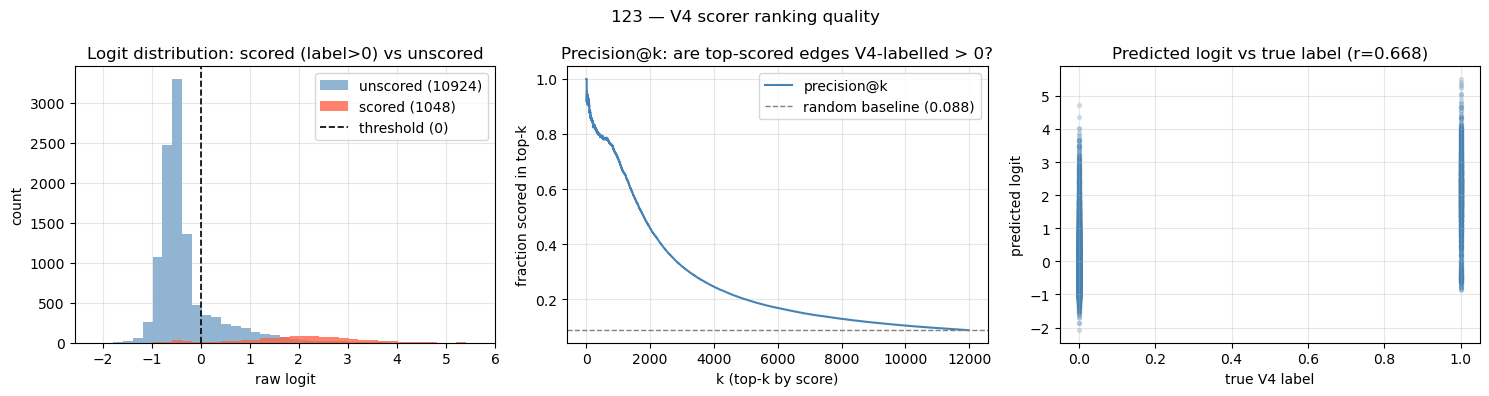

In [20]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

clear_output(wait=True)
plt.close("all")

lbl_bin = (labels_changed.cpu() > 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logit histogram: scored vs unscored
all_vals = np.concatenate([pos_logits, neg_logits])
lo, hi = all_vals.min() - 0.1, all_vals.max() + 0.1
bins = np.linspace(lo, hi, 40)

axes[0].hist(neg_logits, bins=bins, alpha=0.6, label=f'unscored ({len(neg_logits)})', color='steelblue')
axes[0].hist(pos_logits, bins=bins, alpha=0.8, label=f'scored ({len(pos_logits)})', color='tomato')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.2, label='threshold (0)')
axes[0].set_xlabel('raw logit')
axes[0].set_ylabel('count')
axes[0].set_title('Logit distribution: scored (label>0) vs unscored')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision@k
sort_order_logit = all_logits.argsort(descending=True)
sorted_lbl_bin = lbl_bin[sort_order_logit].numpy().astype(float)
cum_pos = sorted_lbl_bin.cumsum()
rank = np.arange(1, len(sorted_lbl_bin) + 1)
random_base = lbl_bin.float().mean().item()

axes[1].plot(rank, cum_pos / rank, color='steelblue', linewidth=1.5, label='precision@k')
axes[1].axhline(random_base, color='grey', linestyle='--', linewidth=1, label=f'random baseline ({random_base:.3f})')
axes[1].set_xlabel('k (top-k by score)')
axes[1].set_ylabel('fraction scored in top-k')
axes[1].set_title('Precision@k: are top-scored edges V4-labelled > 0?')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Correlation
lbl_cont = labels_changed.detach().cpu().numpy().reshape(-1)
lg_np = all_logits.detach().cpu().numpy().reshape(-1)

print(lbl_cont.shape, lg_np.shape)

axes[2].scatter(lbl_cont, lg_np, alpha=0.2, s=8, color='steelblue')
axes[2].set_xlabel('true V4 label')
axes[2].set_ylabel('predicted logit')
axes[2].set_title('Predicted logit vs true continuous label')

if lbl_cont.std() > 1e-8 and lg_np.std() > 1e-8:
    corr = float(np.corrcoef(lbl_cont, lg_np)[0, 1])
    axes[2].set_title(f'Predicted logit vs true label (r={corr:.3f})')

axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 scorer ranking quality', fontsize=12)
plt.tight_layout()
plt.show()

AUC-ROC (scored vs unscored): 0.9392
Avg Precision:                0.7017  (random baseline = 0.0875)


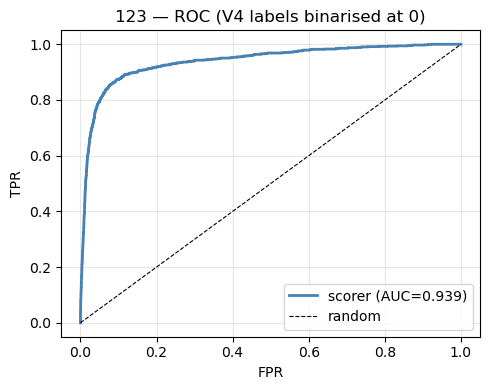

In [21]:
try:
    from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
    y_true  = lbl_bin.numpy().astype(int)
    y_score = all_logits.numpy()

    auc = roc_auc_score(y_true, y_score)
    ap  = average_precision_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    print(f'AUC-ROC (scored vs unscored): {auc:.4f}')
    print(f'Avg Precision:                {ap:.4f}  (random baseline = {random_base:.4f})')

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'scorer (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='random')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{123} — ROC (V4 labels binarised at 0)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('sklearn not available — skipping ROC')

---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [22]:
from collections import defaultdict

src_np    = src.cpu().numpy()
dst_np    = dst.cpu().numpy()
lbl_np_cn = labels_changed.cpu().numpy()
lg_np_cn  = all_logits.numpy()

node_to_cands = defaultdict(list)
for i in range(len(src_np)):
    u, v  = int(src_np[i]), int(dst_np[i])
    entry = (i, bool(lbl_np_cn[i] > 0), float(lbl_np_cn[i]), float(lg_np_cn[i]))
    node_to_cands[u].append(entry)
    node_to_cands[v].append(entry)

node_rows = []
for node, cands in node_to_cands.items():
    n_inc     = len(cands)
    n_pos_cn  = sum(1 for _, is_pos, _, _ in cands if is_pos)
    p_lgts    = [lg for _, is_pos, _, lg in cands if is_pos]
    n_lgts    = [lg for _, is_pos, _, lg in cands if not is_pos]
    node_rows.append({
        'node':           node,
        'degree':         int(degrees[node]),
        'n_incident':     n_inc,
        'n_scored':       n_pos_cn,
        'scored_rate':    n_pos_cn / n_inc,
        'mean_score_pos': float(np.mean(p_lgts)) if p_lgts else float('nan'),
        'mean_score_neg': float(np.mean(n_lgts)) if n_lgts else float('nan'),
    })

node_df = pd.DataFrame(node_rows)
print(f'Nodes with at least one incident candidate: {len(node_df)}')
print(f"Nodes with >= 1 scored candidate: {(node_df['n_scored'] > 0).sum()}")
display(node_df.describe())

Nodes with at least one incident candidate: 2810
Nodes with >= 1 scored candidate: 1148


,node,degree,n_incident,n_scored,scored_rate,mean_score_pos,mean_score_neg
count,2810.000000,2810.000000,2810.000000,2810.000000,2810.000000,1148.000000,2802.000000
mean,1404.500000,5.680427,8.520996,0.745907,0.088241,1.843093,-0.256371
std,811.321453,8.453357,2.858429,1.288084,0.150484,1.098170,0.519443
min,0.000000,1.000000,1.000000,0.000000,0.000000,-0.855057,-1.175105
25%,702.250000,2.000000,6.000000,0.000000,0.000000,1.250699,-0.555926
50%,1404.500000,4.000000,8.000000,0.000000,0.000000,1.943865,-0.391697
75%,2106.750000,7.000000,10.000000,1.000000,0.125000,2.544330,-0.139780
max,2809.000000,246.000000,18.000000,11.000000,1.000000,5.372394,3.769272


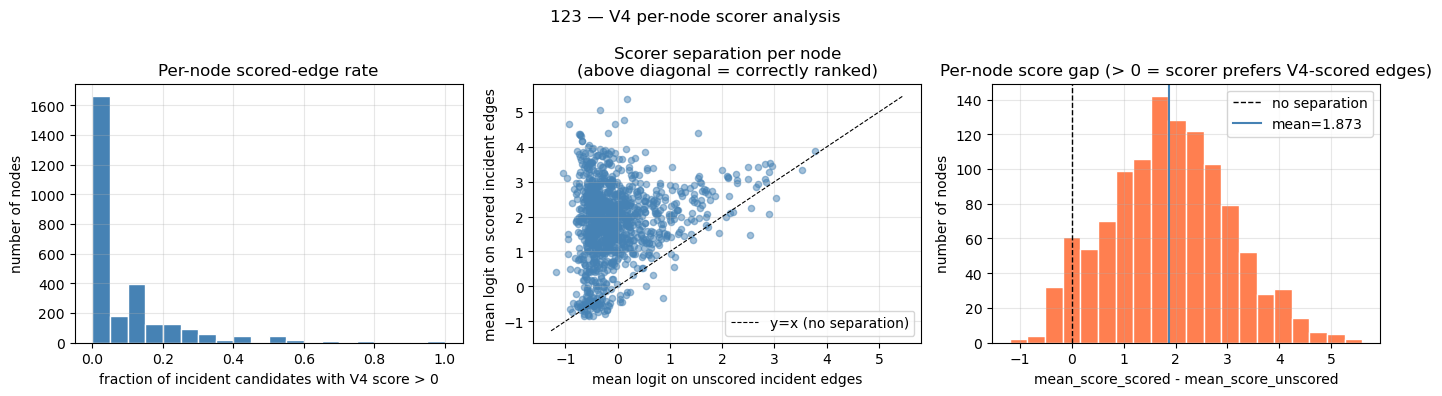

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(node_df['scored_rate'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('fraction of incident candidates with V4 score > 0')
axes[0].set_ylabel('number of nodes')
axes[0].set_title('Per-node scored-edge rate')
axes[0].grid(True, alpha=0.3)

has_both = node_df.dropna(subset=['mean_score_pos', 'mean_score_neg'])
axes[1].scatter(has_both['mean_score_neg'], has_both['mean_score_pos'],
                alpha=0.5, s=20, color='steelblue')
lo = min(has_both['mean_score_neg'].min(), has_both['mean_score_pos'].min()) - 0.1
hi = max(has_both['mean_score_neg'].max(), has_both['mean_score_pos'].max()) + 0.1
axes[1].plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, label='y=x (no separation)')
axes[1].set_xlabel('mean logit on unscored incident edges')
axes[1].set_ylabel('mean logit on scored incident edges')
axes[1].set_title('Scorer separation per node\n(above diagonal = correctly ranked)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

hb = has_both.copy()
hb['score_gap'] = hb['mean_score_pos'] - hb['mean_score_neg']
axes[2].hist(hb['score_gap'], bins=20, color='coral', edgecolor='white')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1, label='no separation')
axes[2].axvline(hb['score_gap'].mean(), color='steelblue', linestyle='-',
                linewidth=1.5, label=f"mean={hb['score_gap'].mean():.3f}")
axes[2].set_xlabel('mean_score_scored - mean_score_unscored')
axes[2].set_ylabel('number of nodes')
axes[2].set_title('Per-node score gap (> 0 = scorer prefers V4-scored edges)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{123} — V4 per-node scorer analysis', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Model Guided PR-BCD

In [40]:
from DeleteCache import delete_pert_files_and_folders
from timeit import default_timer as timer

delete_pert_files_and_folders(
    cache_dir="cache",
    pert_adj_storage_type="evasion_global_adj",
    pert_attr_storage_type="evasion_global_attr",
)

attack_params = {
    "block_size": 100_000,
    "epochs": 100,
    "fine_tune_epochs": 50,
    "keep_heuristic": "WeightOnly",
    "do_synchronize": True,
    "loss_type": "tanhMargin",
}

selector_params = {
    "accuracy_drop_selector_mode": "one_sample",
    "n_candidates_k_sample": 2_000,
    "n_candidates_one_sample": 5_000,
    "drop_mode": "endpoint",
    "acc_drop_threshold_k_samples": 1e-3,
    "loss_drop_threshold_k_samples": 1e-3,
    "k_samples_batch": 10,
    "training_data_node_cap": 15,

    "tau": 0.8,
    "score_batch_size": 1_000,
    "max_sampling_tries": 2_000_000,
    "exclude_tried": True,

    "lp_hit_rate_detour": False,
    "lp_hit_rate_top_k": 200,
    "lp_hit_rate_out_dir": (
        "extendedPlotting/lpEndpointHitRate"
    ),
}
# ============================================================
# Construct SparseGraph required by the LP-selector functions
# ============================================================

from sparse_smoothing.utils import load_and_standardize

graph_sparse = load_and_standardize(
    os.path.join("data", f"{DATASET}.npz")
)

assert hasattr(graph_sparse, "attr_matrix")
assert hasattr(graph_sparse, "adj_matrix")
assert hasattr(graph_sparse, "labels")

print(
    "graph_sparse:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)

start = timer()

result = experiment_global_attack_direct.run(
    # Important: SparseGraph, not train_statistics["graph"]
    graph=graph_sparse,

    data_dir="./data",
    dataset=DATASET,
    attack="PRBCD",

    attack_params=attack_params,
    selector_params=selector_params,

    epsilons=[0.05],
    binary_attr=False,
    make_undirected=True,

    # Must match training
    seed=SEED,

    artifact_dir="cache",
    pert_adj_storage_type="evasion_global_adj",
    pert_attr_storage_type="evasion_global_attr",

    # Must exactly match training metadata
    model_label=MODEL_LABEL,
    model_storage_type="demo_custom_split",

    device="cpu",
    data_device="cpu",
    debug_level="info",

    semi=True,
    use_cert="accuracy_drop_selector",
)

elapsed = timer() - start

print("Runtime:", elapsed)
print("Final accuracy:", result["results"][0]["accuracy"])
print(result)

Not found: cache\evasion_global_adj.json
Not found: cache\evasion_global_attr.json
Not found: cache\evasion_global_adj
Not found: cache\evasion_global_attr
graph_sparse: nodes=2810 features=2879 directed_edges=15962


[06/22/26 14:53:51] INFO     {'dataset': 'cora_ml', 'attack': 'PRBCD', 'attack_params': {'block_size': ]8;id=453346;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=696070;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             100000, 'epochs': 100, 'fine_tune_epochs': 50, 'keep_heuristic':                      
                             'WeightOnly', 'do_synchronize': True, 'loss_type': 'tanhMargin'},                     
                             'epsilons': [0.05], 'make_undirected': True, 'binary_attr': False,                    
                             'seed': 0, 'artifact_dir': 'cache', 'pert_adj_storage_type':                          
                             'evasion_global_adj', 'pert_attr_storage_type': 'evasion_global_attr',                
                             'model_label': 'GCN', 'model_storage_type': 'demo_custom_split',                      
                             'device': 'cpu', 'data_device': 'cpu'}                                                

                    INFO     Lock 2243937379600 acquired on cache\demo_custom_split.json.lock       ]8;id=557378;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=292868;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2243937379600 released on cache\demo_custom_split.json.lock       ]8;id=15136;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=867864;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Evaluate PRBCD for model 'GCN'.                 ]8;id=232520;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py\experiment_global_attack_direct.py]8;;\:]8;id=138000;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py#101\101]8;;\

...

                    INFO     Lock 2243971113936 acquired on cache\evasion_global_attr.json.lock     ]8;id=526946;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=908659;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 2243971113936 released on cache\evasion_global_attr.json.lock     ]8;id=12839;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=462579;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     No cached perturbations found for model 'GCN' and eps 0.05. Execute      ]8;id=716876;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=213918;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#135\135]8;;\
                             attack...                                                                             

accuracy_drop_selector -> sampling with accuracy drop selector
[CACHE] computing selection and saving: cache/selection_datasetcora_ml_seed0_ads_one_sample_k5000_drpmdendpoint_trnodecap15
[HARMFUL EDGE FOUND] k=1514155 | edge=(603, 2435) | action=add | mode=endpoint | found=1/5000
[HARMFUL EDGE FOUND] k=445432 | edge=(163, 932) | action=add | mode=endpoint | found=2/5000
[HARMFUL EDGE FOUND] k=2820395 | edge=(1308, 2310) | action=add | mode=endpoint | found=3/5000
[HARMFUL EDGE FOUND] k=513498 | edge=(189, 553) | action=add | mode=endpoint | found=4/5000
[HARMFUL EDGE FOUND] k=2140118 | edge=(908, 2233) | action=add | mode=endpoint | found=5/5000
[HARMFUL EDGE FOUND] k=2118653 | edge=(897, 1734) | action=add | mode=endpoint | found=6/5000
[HARMFUL EDGE FOUND] k=1513446 | edge=(603, 1726) | action=add | mode=endpoint | found=7/5000
[HARMFUL EDGE FOUND] k=3676397 | edge=(2074, 2307) | action=add | mode=endpoint | found=8/5000


KeyboardInterrupt: 